# Sensitivity of the phenotypic-AM SEM-PGS model to the mechanism of assortment

The equilibrium `UniSEMPGS_SameTrait_ObservedYPYM` model assumes spouses assort on the **phenotype**.
Here it is fit to data from `01_simulate.py`, in which two independent traits are simulated in the same
population: trait 1 assorts on the **total genetic value** (genetic AM) and trait 2 on the **familial +
unique environment** (social AM). The assortment strengths were calibrated (`00_calibrate_am.py`) so that
both traits reach a phenotypic spousal correlation of ≈ `R_SPOUSE_Y` after `N_GENERATIONS` generations.

* Estimates: `02_fit_models.R` → `output/results/estimates.csv`
* Truth (per replicate, `output/truth/`): generating values for `delta`, `a`, `f`, `VE`; empirical
  population values of the parental generation for everything else (`VY`, `mu = cov(Yp,Ym)/VY²`, `Omega`,
  `Gamma`, haplotype covariances `gt/ht/gc/hc/ic`, `w`, `v`, and `VF_sim = var(F)`).
* `VF` is not a free parameter; it is computed from the estimates with the model's own algebra,
  `VF = 2 f² VY + 2 f² VY² mu`, and compared with `var(F)` taken directly from the simulation.
* Bias = estimate − truth. The freely estimated means are nuisance parameters and are not shown.

In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import sim_conditions as C

OUT = "output"
PLOTS = os.path.join(OUT, "plots"); os.makedirs(PLOTS, exist_ok=True)

COND_LABEL = {"geneticAM": "Genetic AM", "socialAM": "Social AM", "phenotypicAM": "Phenotypic AM"}
COND_COLOR = {"Genetic AM": "#2a78d6", "Social AM": "#eb6834", "Phenotypic AM": "#1baf7a"}  # fixed categorical slots
PARAMS = ["delta", "a", "f", "VE", "VF", "VY", "mu", "Omega", "Gamma", "gt", "ht", "gc", "hc", "ic", "w", "v"]

mpl.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#999999",
    "axes.grid": True, "grid.color": "#e6e6e6", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 10, "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 9,
})

print({k: getattr(C, k) for k in ["N_REPS", "POP_SIZE", "N_GENERATIONS", "N_CV", "VG", "PROP_OBS", "VE", "F", "R_SPOUSE_Y", "TRAITS", "AM"]})

{'N_REPS': 100, 'POP_SIZE': 4000, 'N_GENERATIONS': 15, 'N_CV': 1000, 'VG': 0.5, 'PROP_OBS': 0.4, 'VE': 0.5, 'F': 0.15, 'R_SPOUSE_Y': 0.4, 'TRAITS': {1: 'genotypic', 2: 'social'}, 'AM': {'genotypic': 0.547, 'social': 0.649, 'phenotypic': 0.4}}


## Load estimates and truth; derive VF

In [2]:
est   = pd.read_csv(f"{OUT}/results/estimates.csv")
truth = pd.concat(map(pd.read_csv, sorted(glob.glob(f"{OUT}/truth/rep*_truth.csv"))), ignore_index=True)
diag  = pd.concat(map(pd.read_csv, sorted(glob.glob(f"{OUT}/truth/rep*_summary.csv"))), ignore_index=True)
est = est[est["parameter"].notna() & ~est["parameter"].str.startswith("mean")]

# VF from the model algebra applied to the estimates, and the same algebra applied to the true values
e = est.pivot(index=["rep", "condition"], columns="parameter", values="estimate")
t = truth.pivot(index=["rep", "condition"], columns="parameter", values="true")
vf = pd.DataFrame({
    "VF_est":      2 * e["f11"]**2 * e["VY11"] * (1 + e["VY11"] * e["mu11"]),
    "VF_alg_true": 2 * t["f11"]**2 * t["VY11"] * (1 + t["VY11"] * t["mu11"]),
    "VF_sim":      t["VF_sim"],
}).reset_index()

fit_status = est.drop_duplicates(["rep", "condition"]).set_index(["rep", "condition"])["statusCode"]
est_vf = vf[["rep", "condition"]].assign(parameter="VF11", estimate=vf["VF_est"], SE=np.nan,
                                         statusCode=fit_status.reindex(pd.MultiIndex.from_frame(vf[["rep", "condition"]])).to_numpy())
truth_vf = vf[["rep", "condition"]].assign(parameter="VF11", true=vf["VF_sim"])

d = pd.concat([est, est_vf], ignore_index=True).merge(pd.concat([truth, truth_vf], ignore_index=True),
                                                      on=["rep", "condition", "parameter"])
d["parameter"] = pd.Categorical(d["parameter"].str.replace("11$", "", regex=True), PARAMS, ordered=True)
d = d[d["parameter"].notna()]
for df in (d, diag, vf):
    df["condition"] = df["condition"].map(COND_LABEL)
d["bias"] = d["estimate"] - d["true"]
d["converged"] = d["statusCode"].isin(["OK", "OK/green"])
conds = [c for c in COND_COLOR if c in set(d["condition"])]

fits = est.drop_duplicates(["rep", "condition"]).assign(condition=lambda x: x["condition"].map(COND_LABEL))
print(f"{fits['rep'].nunique()} replicates; fits per condition: {fits['condition'].value_counts().to_dict()}")
fits.groupby("condition")["statusCode"].value_counts().unstack(fill_value=0)

100 replicates; fits per condition: {'Genetic AM': 100, 'Social AM': 100}


statusCode,OK
condition,
Genetic AM,100
Social AM,100


## Simulation diagnostics: did the calibration hold?

Realised values in the parental generation of each replicate (mean and SD over replicates).
`r_spouse_Y` should be ≈ `R_SPOUSE_Y` for both conditions; `r_spouse_A` / `r_spouse_FE` are the correlations
of the two mating variables. **`h2` here is the realised total narrow-sense heritability,
`var(AO + AL) / var(Y)`, in the parental generation** — i.e. after 15 generations of AM and VT have
inflated the genetic variance (genetic AM) or the familial variance (social AM). It is not the
generation-0 value `VG / (VG + VE)` and not the model's implied heritability.

In [3]:
diag_cols = ["n_trios", "VY", "h2", "r_spouse_Y", "r_spouse_A", "r_spouse_FE"]
diag.groupby("condition")[diag_cols].agg(["mean", "std"]).round(3)

n_trios             VY            h2        r_spouse_Y         \
               mean     std   mean    std   mean    std       mean    std   
condition                                                                   
Genetic AM  1649.15  16.058  2.221  0.114  0.451  0.009      0.402  0.018   
Social AM   1649.15  16.058  1.295  0.053  0.393  0.011      0.396  0.020   

           r_spouse_A        r_spouse_FE         
                 mean    std        mean    std  
condition                                        
Genetic AM      0.542  0.015       0.068  0.024  
Social AM       0.027  0.025       0.641  0.013

## Bias per parameter

`std_bias` = mean bias divided by the SD of the estimates across replicates, i.e. bias in units of the
sampling variability at this sample size; `rel_bias_pct` = 100 × mean bias / mean truth (unstable when the
truth is near zero, e.g. the spousal haplotype covariances under social AM).

In [4]:
g = d.groupby(["condition", "parameter"], observed=True)
summ = g.agg(n=("bias", "size"), n_converged=("converged", "sum"),
             mean_true=("true", "mean"), mean_est=("estimate", "mean"),
             mean_bias=("bias", "mean"), mc_se=("bias", "sem"), sd_est=("estimate", "std"),
             rmse=("bias", lambda b: float(np.sqrt(np.mean(b ** 2)))), mean_SE=("SE", "mean")).reset_index()
summ["rel_bias_pct"] = 100 * summ["mean_bias"] / summ["mean_true"]
summ["std_bias"] = summ["mean_bias"] / summ["sd_est"]
summ.to_csv(f"{OUT}/results/bias_summary.csv", index=False)

wide = summ.pivot(index="parameter", columns="condition", values=["mean_true", "mean_bias", "rel_bias_pct", "std_bias"])
wide = wide.reindex(columns=[(v, c) for v in ["mean_true", "mean_bias", "rel_bias_pct", "std_bias"] for c in conds])
wide.round(3)

mean_true            mean_bias           rel_bias_pct            \
condition Genetic AM Social AM Genetic AM Social AM   Genetic AM Social AM   
parameter                                                                    
delta          0.448     0.446      0.000    -0.008        0.083    -1.899   
a              0.548     0.549     -0.017    -0.130       -3.179   -23.729   
f              0.150     0.150      0.064    -0.008       42.988    -5.556   
VE             0.500     0.500      0.008     0.081        1.540    16.201   
VF             0.138     0.080      0.155     0.007      112.062     8.293   
VY             2.221     1.295     -0.033     0.002       -1.484     0.178   
mu             0.179     0.303      0.005     0.004        2.887     1.377   
Omega          0.576     0.273     -0.015     0.006       -2.595     2.060   
Gamma          0.707     0.335     -0.180    -0.012      -25.507    -3.606   
gt             0.106     0.003     -0.041     0.032      -38.319  1088.818   
ht             0.158     0.005     -0.107     0.029      -67.407   610.917   
gc             0.106     0.003     -0.013     0.001      -11.813    22.964   
hc             0.159     0.003     -0.107     0.031      -67.532  1048.018   
ic             0.127     0.003     -0.073     0.024      -57.287   708.098   
w              0.260     0.092      0.077     0.019       29.443    20.177   
v              0.319     0.112     -0.009     0.003       -2.757     2.510   

            std_bias            
condition Genetic AM Social AM  
parameter                       
delta          0.011    -0.238  
a             -0.202    -0.994  
f              1.554    -0.135  
VE             0.114     1.044  
VF             1.372     0.114  
VY            -0.295     0.046  
mu             0.580     0.197  
Omega         -0.404     0.310  
Gamma         -2.702    -0.144  
gt            -4.711     5.812  
ht            -8.785     1.861  
gc            -0.820     0.080  
hc            -8.835     1.977  
ic            -8.610     3.474  
w              1.193     0.376  
v             -0.235     0.068

### VF: model algebra vs the simulation

* `VF_sim` — `var(F)` of the parental generation, taken directly from the simulation.
* `VF_alg_true` — the model's algebra `2 f² VY (1 + VY mu)` evaluated at the **true** `f`, `VY`, `mu`.
  Its difference from `VF_sim` tests whether the algebra itself holds under each mating mechanism
  (it should: `F = f (Yp + Ym)` in the simulation, so `var(F) = 2 f² VY + 2 f² cov(Yp, Ym)`).
* `VF_est` — the same algebra evaluated at the **estimated** `f`, `VY`, `mu`; `VF_est − VF_sim` is the
  bias plotted in the `VF` panel below.

In [5]:
vf["alg_minus_sim"] = vf["VF_alg_true"] - vf["VF_sim"]
vf["est_minus_sim"] = vf["VF_est"] - vf["VF_sim"]
vf.groupby("condition")[["VF_sim", "VF_alg_true", "VF_est", "alg_minus_sim", "est_minus_sim"]].agg(["mean", "std"]).round(4)

VF_sim         VF_alg_true          VF_est         alg_minus_sim  \
              mean     std        mean     std    mean     std          mean   
condition                                                                      
Genetic AM  0.1380  0.0086      0.1396  0.0081  0.2927  0.1127        0.0016   
Social AM   0.0799  0.0043      0.0811  0.0033  0.0866  0.0580        0.0011   

                   est_minus_sim          
               std          mean     std  
condition                                 
Genetic AM  0.0037        0.1547  0.1122  
Social AM   0.0032        0.0066  0.0585

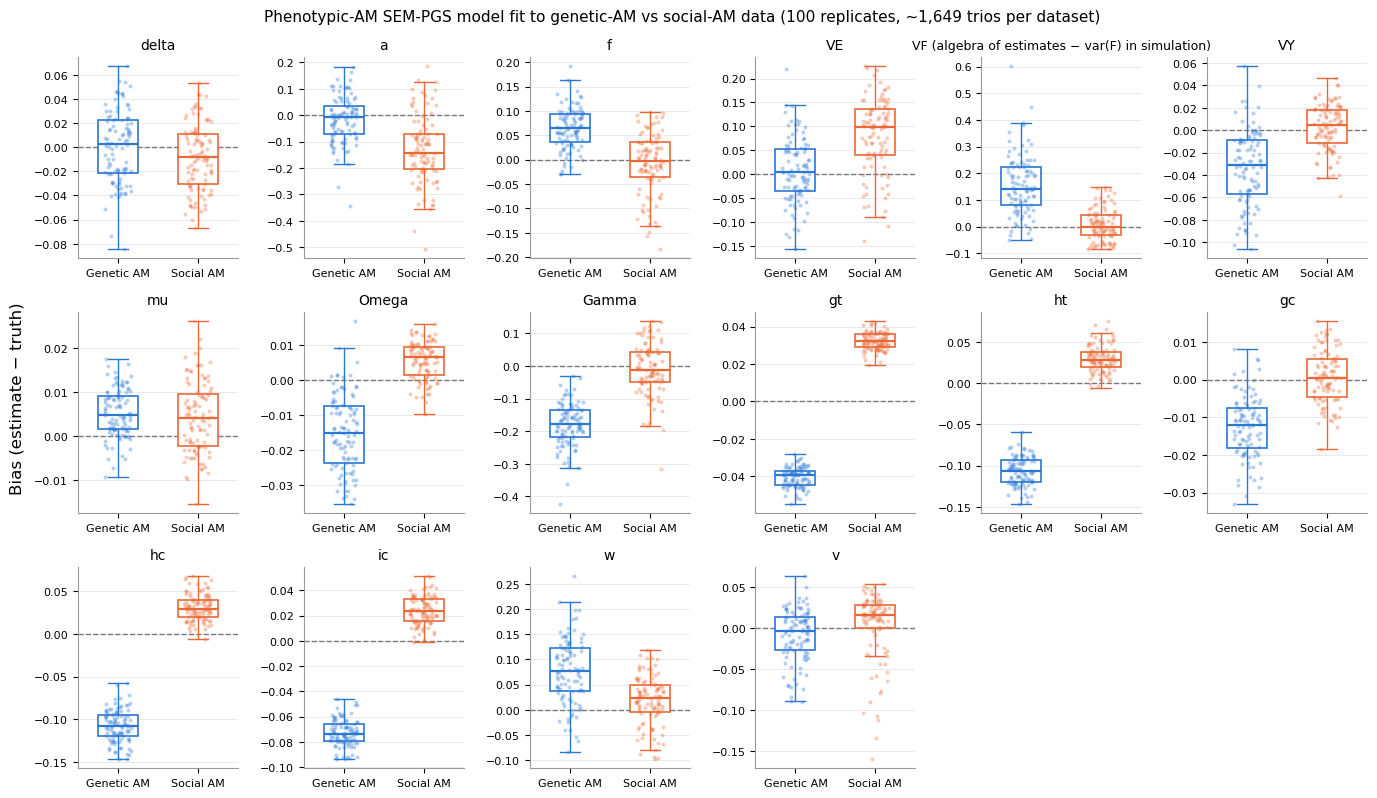

In [6]:
def box_strip(ax, df, value, rng, width=0.5):
    for k, c in enumerate(conds):
        vals = df.loc[df["condition"] == c, value].to_numpy()
        col = COND_COLOR[c]
        ax.boxplot([vals], positions=[k], widths=width, showfliers=False, patch_artist=True,
                   boxprops=dict(facecolor="white", edgecolor=col, lw=1.2), medianprops=dict(color=col, lw=1.6),
                   whiskerprops=dict(color=col, lw=1), capprops=dict(color=col, lw=1), zorder=2)
        ax.scatter(k + rng.uniform(-0.17, 0.17, len(vals)), vals, s=8, color=col, alpha=0.35, lw=0, zorder=3)
    ax.set_xticks(range(len(conds))); ax.set_xticklabels(conds); ax.grid(axis="x", visible=False)

ncol = 6; nrow = int(np.ceil(len(PARAMS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 2.7 * nrow))
rng = np.random.default_rng(1)
for ax, p in zip(axes.flat, PARAMS):
    ax.axhline(0, color="#777777", lw=1, ls="--", zorder=1)
    box_strip(ax, d[d["parameter"] == p], "bias", rng)
    ax.set_title(p if p != "VF" else "VF (algebra of estimates − var(F) in simulation)", fontsize=9 if p == "VF" else 10)
for ax in axes.flat[len(PARAMS):]:
    ax.axis("off")
fig.supylabel("Bias (estimate − truth)")
fig.suptitle(f"Phenotypic-AM SEM-PGS model fit to genetic-AM vs social-AM data "
             f"({fits['rep'].nunique()} replicates, ~{int(fits['n'].mean()):,} trios per dataset)", fontsize=11)
fig.tight_layout(); fig.savefig(f"{PLOTS}/bias_boxplots.png"); plt.show()

Outputs written: `output/results/bias_summary.csv`, `output/plots/bias_boxplots.png`.